In [311]:
import torch
import torch.nn as nn
import torchaudio
import torchaudio.functional as F
import soundfile as sf
import numpy as np
print(torch.__version__)
print(torchaudio.__version__)
import os
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from torch.utils.data import DataLoader, TensorDataset, random_split
import os
import pandas as pd

2.10.0+cu130
2.10.0+cu130


In [ ]:


# def build_mimii_pump_dataframe(root_dir):
#     records = []

#     for machine_id in os.listdir(root_dir):
#         machine_path = os.path.join(root_dir, machine_id)

#         if not os.path.isdir(machine_path):
#             continue

#         for condition in ["normal", "abnormal"]:
#             condition_path = os.path.join(machine_path, condition)

#             if not os.path.exists(condition_path):
#                 continue

#             for file in os.listdir(condition_path):
#                 if file.endswith(".wav"):
#                     records.append({
#                         "machine_id": machine_id,
#                         "condition": condition,
#                         "file_path": os.path.join(condition_path, file)
#                     })

#     return pd.DataFrame(records)

In [314]:
def build_mimii_pump_dataframe(root_dir):
    records = []
    machine_path= root_dir

    for condition in ["normal", "abnormal"]:
        condition_path = os.path.join(machine_path, condition)

        if not os.path.exists(condition_path):
            continue

        for file in os.listdir(condition_path):
            if file.endswith(".wav"):
                records.append({
                    "machine_id": "id_00",
                    "condition": condition,
                    "file_path": os.path.join(condition_path, file)
                })

    return pd.DataFrame(records)

In [315]:
root_dir = r"data\0_dB_pump\pump\id_00"
df = build_mimii_pump_dataframe(root_dir)

print(df.head())
print(df["condition"].value_counts())

  machine_id condition                                      file_path
0      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000000.wav
1      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000001.wav
2      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000002.wav
3      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000003.wav
4      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000004.wav
condition
normal      1006
abnormal     143
Name: count, dtype: int64


In [316]:
df["label"] = df["condition"].map({"normal": 0, "abnormal": 1})

In [317]:
print(df.groupby("machine_id")["label"].value_counts())

machine_id  label
id_00       0        1006
            1         143
Name: count, dtype: int64


In [318]:

TARGET_SR = 16000
SEGMENT_DURATION = 5  # seconds

def preprocess_and_segment(file_path):
    # Load
    y, _ = librosa.load(file_path, sr=TARGET_SR, mono=True)

    # Normalize
    y = librosa.util.normalize(y)

    # Segment length
    segment_length = TARGET_SR * SEGMENT_DURATION

    segments = []

    for i in range(0, len(y), segment_length):
        segment = y[i:i+segment_length]
        if len(segment) == segment_length:
            segments.append(segment)

    return np.array(segments)

In [319]:
from tqdm import tqdm

all_segments = []
all_labels = []
all_machine_ids = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    segments = preprocess_and_segment(row["file_path"])

    for seg in segments:
        all_segments.append(seg)
        all_labels.append(row["label"])
        all_machine_ids.append(row["machine_id"])

X_audio = np.array(all_segments)
y = np.array(all_labels)
machine_ids = np.array(all_machine_ids)

print("Segments shape:", X_audio.shape)
print("Labels shape:", y.shape)

100%|██████████| 1149/1149 [00:18<00:00, 60.73it/s]


Segments shape: (2298, 80000)
Labels shape: (2298,)


In [18]:
np.save("X_audio.npz",X_audio)
np.save("y_label.npz",y)

In [320]:

unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(2012), np.int64(1): np.int64(286)}


In [321]:
def extract_descriptors(segment):
    mfcc = librosa.feature.mfcc(y=segment, sr=TARGET_SR, n_mfcc=20)
    centroid = librosa.feature.spectral_centroid(y=segment, sr=TARGET_SR)
    bandwidth = librosa.feature.spectral_bandwidth(y=segment, sr=TARGET_SR)
    zcr = librosa.feature.zero_crossing_rate(segment)
    rms = librosa.feature.rms(y=segment)

    feature_vector = np.concatenate([
        mfcc.mean(axis=1),              # 20
        [centroid.mean()],              # 1
        [bandwidth.mean()],             # 1
        [zcr.mean()],                   # 1
        [rms.mean()]                    # 1
    ])

    return feature_vector

In [322]:

feature_list = []

for segment in tqdm(X_audio):
    features = extract_descriptors(segment)
    feature_list.append(features)

X_features = np.array(feature_list)

print("Feature matrix shape:", X_features.shape)

100%|██████████| 2298/2298 [00:39<00:00, 57.52it/s]

Feature matrix shape: (2298, 24)


In [19]:
np.save("UnScaled_Feature Mat.npz",X_features)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (8410, 24)


In [20]:
# df_features = pd.DataFrame(X_scaled)
# df_features["label"] = y

# print(df_features.groupby("label").mean())

              0         1         2         3         4         5         6  \
label                                                                         
0      0.003634  0.011236  0.072178  0.041111  0.094107  0.027273  0.016345   
1     -0.029873 -0.092378 -0.593410 -0.337996 -0.773696 -0.224227 -0.134380   

              7         8         9  ...        14        15        16  \
label                                ...                                 
0      0.082975  0.028274 -0.026632  ... -0.069051 -0.050166 -0.006101   
1     -0.682175 -0.232453  0.218958  ...  0.567703  0.412441  0.050161   

             17        18        19        20        21        22        23  
label                                                                        
0      0.040738 -0.031424 -0.058455 -0.020039  0.008588 -0.036278  0.048425  
1     -0.334924  0.258351  0.480591  0.164750 -0.070608  0.298258 -0.398125  

[2 rows x 24 columns]


In [325]:
import hdbscan

def run_hdbscan(X_scaled):
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=30,
        min_samples=10,
        cluster_selection_method='eom'
    )

    cluster_labels = clusterer.fit_predict(X_scaled)

    return cluster_labels, clusterer

In [323]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_audio)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (2298, 80000)


In [326]:

cluster_labels, clusterer = run_hdbscan(X_scaled)

print("Unique clusters:", np.unique(cluster_labels))
print("Number of clusters (excluding noise):",
      len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0))

Unique clusters: [-1]
Number of clusters (excluding noise): 0


In [108]:
import pandas as pd

cluster_df = pd.DataFrame({
    "cluster": cluster_labels,
    "true_label": y
})

print(cluster_df["cluster"].value_counts())

cluster
-1     3771
 13    3012
 1      726
 7      150
 9      146
 10     139
 12     120
 0       88
 11      52
 5       47
 6       43
 8       37
 2       34
 4       24
 3       21
Name: count, dtype: int64


In [109]:
cluster_df.shape

(8410, 2)

In [111]:
#cluster_df.groupby("cluster")["true_label"].value_counts(normalize=True)

cluster  true_label
-1       0             0.827897
         1             0.172103
 0       0             1.000000
 1       0             1.000000
 2       0             0.970588
         1             0.029412
 3       0             0.952381
         1             0.047619
 4       0             1.000000
 5       1             1.000000
 6       0             0.860465
         1             0.139535
 7       0             0.900000
         1             0.100000
 8       0             1.000000
 9       0             0.993151
         1             0.006849
 10      0             1.000000
 11      0             1.000000
 12      0             0.991667
         1             0.008333
 13      0             0.936587
         1             0.063413
Name: proportion, dtype: float64

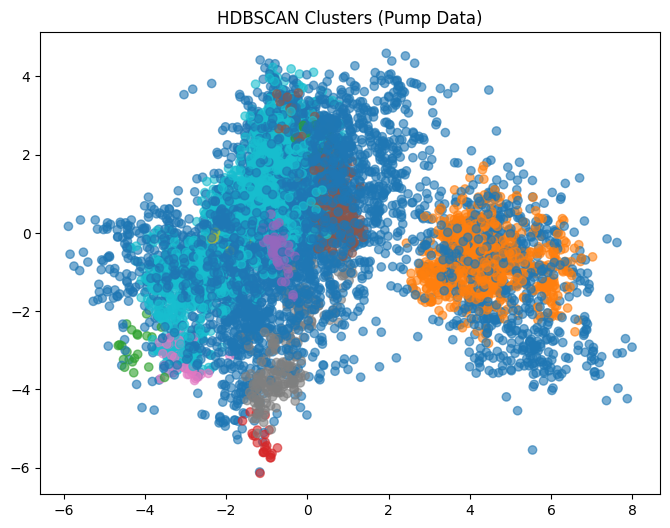

In [110]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=cluster_labels,
            cmap='tab10',
            alpha=0.6)
plt.title("HDBSCAN Clusters (Pump Data)")
plt.show()

In [112]:
import numpy as np
import pandas as pd

mask = cluster_labels != -1

X_valid = X_scaled[mask]
y_valid = y[mask]
clusters_valid = cluster_labels[mask]

In [113]:
cluster_profiles = {}

for c in np.unique(clusters_valid):
    cluster_profiles[c] = X_valid[clusters_valid == c].mean(axis=0)

print("Total valid clusters:", len(cluster_profiles))

Total valid clusters: 14


In [114]:
global_mean = X_valid.mean(axis=0)

In [115]:
cluster_deviation = {}

for c, vec in cluster_profiles.items():
    cluster_deviation[c] = vec - global_mean

In [116]:
for c, dev in cluster_deviation.items():
    print(f"\nCluster {c}")
    top_features = np.argsort(np.abs(dev))[-5:]
    for idx in reversed(top_features):
        print(f"Feature {idx}: deviation {dev[idx]:.3f}")


Cluster 0
Feature 10: deviation 2.798
Feature 15: deviation -2.245
Feature 19: deviation -2.153
Feature 22: deviation 1.989
Feature 17: deviation 1.963

Cluster 1
Feature 12: deviation -1.759
Feature 10: deviation 1.484
Feature 21: deviation 1.462
Feature 22: deviation 1.382
Feature 1: deviation -1.345

Cluster 2
Feature 11: deviation -2.438
Feature 8: deviation 2.249
Feature 9: deviation 1.419
Feature 3: deviation -1.307
Feature 12: deviation -1.179

Cluster 3
Feature 21: deviation -2.441
Feature 1: deviation 2.252
Feature 16: deviation 2.246
Feature 0: deviation -2.174
Feature 20: deviation -1.799

Cluster 4
Feature 19: deviation -2.538
Feature 8: deviation -2.411
Feature 3: deviation -2.157
Feature 16: deviation 1.792
Feature 5: deviation -1.711

Cluster 5
Feature 7: deviation -3.098
Feature 23: deviation -1.745
Feature 8: deviation -1.620
Feature 6: deviation -1.358
Feature 3: deviation -1.298

Cluster 6
Feature 16: deviation -2.185
Feature 3: deviation -1.869
Feature 13: deviatio

In [117]:
cluster_df = pd.DataFrame({
    "cluster": clusters_valid,
    "label": y_valid
})

print(cluster_df.groupby("cluster")["label"].mean())

cluster
0     0.000000
1     0.000000
2     0.029412
3     0.047619
4     0.000000
5     1.000000
6     0.139535
7     0.100000
8     0.000000
9     0.006849
10    0.000000
11    0.000000
12    0.008333
13    0.063413
Name: label, dtype: float64


In [118]:
import scipy.io as sio

file_path = r"data\bearings\0Nm_BPFI_03.mat"
mat_data = sio.loadmat(file_path)

print(mat_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Signal'])


In [119]:
signal = mat_data['Signal'].flatten()
print(signal.shape)

(1,)


In [122]:
mat_data['Signal']

array([[(array([[(array([[3.32288677e-06]]), array([[1.953125e-05]]), array([[3072000]], dtype=int32), array([[(array(['s'], dtype='<U1'), array([[(array([[0]], dtype=uint8), array([[1]], dtype=uint8), array([[1]], dtype=uint8))]],
                              dtype=[('offset', 'O'), ('factor', 'O'), ('log_reference', 'O')]), array([[(array([[0]], dtype=uint8), array([[1]], dtype=uint8), array(['LENGTH'], dtype='<U6')),
                                (array([[0]], dtype=uint8), array([[1]], dtype=uint8), array(['ANGLE'], dtype='<U5')),
                                (array([[0]], dtype=uint8), array([[1]], dtype=uint8), array(['MASS'], dtype='<U4')),
                                (array([[1]], dtype=uint8), array([[1]], dtype=uint8), array(['TIME'], dtype='<U4')),
                                (array([[0]], dtype=uint8), array([[1]], dtype=uint8), array(['CURRENT'], dtype='<U7')),
                                (array([[0]], dtype=uint8), array([[1]], dtype=uint8), array(['LIGH

In [129]:
container = mat_data['Signal'][0][0]

# Extract y_values
y_struct = container['y_values'][0][0]

# Extract actual numeric waveform
signal = y_struct['values']

# Flatten to 1D
signal = signal.flatten()

print(signal.shape)

(3072000,)


In [131]:
increment = container['x_values'][0][0]['increment'][0][0]
fs = 1 / increment
print(fs)

51200.0


In [158]:
import scipy.io as sio
import numpy as np
import librosa

TARGET_SR = 16000
SEGMENT_DURATION = 5

def extract_signal_from_mat(file_path):
    mat_data = sio.loadmat(file_path)

    # Identify main variable (exclude metadata)
    main_key = [k for k in mat_data.keys() if not k.startswith("__")][0]

    container = mat_data[main_key][0][0]

    # Extract waveform
    signal = container['y_values'][0][0]['values']
    signal = signal.flatten().astype(float)

    # Extract sampling rate
    increment = container['x_values'][0][0]['increment'][0][0]
    fs = 1 / increment

    return signal, fs


def preprocess_bearing_signal(signal, orig_sr):
    # Resample
    signal_resampled = librosa.resample(signal, orig_sr=orig_sr, target_sr=TARGET_SR)

    # Normalize
    signal_resampled = librosa.util.normalize(signal_resampled)

    # Segment
    segment_length = TARGET_SR * SEGMENT_DURATION
    segments = []

    for i in range(0, len(signal_resampled), segment_length):
        seg = signal_resampled[i:i+segment_length]
        if len(seg) == segment_length:
            segments.append(seg)

    return np.array(segments)

In [220]:
bearing_files = {
    #r"data\bearings\0Nm_BPFI_03.mat": "inner_ring",
    r"data\bearings\0Nm_BPFI_10.mat": "inner_ring",
    #r"data\bearings\0Nm_BPFO_03.mat": "outer_ring",
    r"data\bearings\0Nm_BPFO_10.mat": "outer_ring"#,
    # r"data\bearings\0Nm_Normal.mat": "normal"
}

bearing_features = []
bearing_labels = []

for file, label in bearing_files.items():
    signal, fs = extract_signal_from_mat(file)
    segments = preprocess_bearing_signal(signal, fs)

    print(f"{file} → Segments:", segments.shape[0])

    for seg in segments:
        features = extract_descriptors(seg)
        bearing_features.append(features)
        bearing_labels.append(label)

bearing_features = np.array(bearing_features)
bearing_labels = np.array(bearing_labels)

print("Total feature matrix:", bearing_features.shape)

data\bearings\0Nm_BPFI_10.mat → Segments: 12
data\bearings\0Nm_BPFO_10.mat → Segments: 12
Total feature matrix: (24, 24)


In [221]:
from sklearn.preprocessing import StandardScaler

bearing_scaler = StandardScaler()
bearing_scaled = bearing_scaler.fit_transform(bearing_features)

In [222]:
fault_library_bearing = {}

for fault in np.unique(bearing_labels):
    fault_data = bearing_scaled[bearing_labels == fault]

    fault_library_bearing[fault] = {
        "mean": fault_data.mean(axis=0),
        "cov": np.cov(fault_data.T)
    }

print("Bearing Fault Types:", fault_library_bearing.keys())

Bearing Fault Types: dict_keys([np.str_('inner_ring'), np.str_('outer_ring')])


In [223]:
X_pump_bearing_space = bearing_scaler.transform(X_features)

In [224]:
import numpy as np

mask = cluster_labels != -1

X_valid = X_pump_bearing_space[mask]
clusters_valid = cluster_labels[mask]

In [225]:
cluster_means = {}

for c in np.unique(clusters_valid):
    cluster_means[c] = X_valid[clusters_valid == c].mean(axis=0)

print("Clusters available:", cluster_means.keys())

Clusters available: dict_keys([np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)])


In [226]:
from scipy.spatial.distance import mahalanobis
import numpy.linalg as LA

def compute_mahalanobis(vec, mean, cov):
    cov_inv = LA.pinv(cov)  # use pseudo-inverse for stability
    return mahalanobis(vec, mean, cov_inv)

In [227]:
cluster_fault_mapping = {}

for cluster_id, cluster_vec in cluster_means.items():

    best_fault = None
    min_distance = float("inf")

    for fault, stats in fault_library_bearing.items():

        dist = compute_mahalanobis(
            cluster_vec,
            stats["mean"],
            stats["cov"]
        )

        if dist < min_distance:
            min_distance = dist
            best_fault = fault

    cluster_fault_mapping[cluster_id] = {
        "matched_fault": best_fault,
        "distance": min_distance
    }

print(cluster_fault_mapping)

{np.int64(0): {'matched_fault': np.str_('outer_ring'), 'distance': np.float64(323.09687403328957)}, np.int64(1): {'matched_fault': np.str_('outer_ring'), 'distance': np.float64(349.32012790999545)}, np.int64(2): {'matched_fault': np.str_('outer_ring'), 'distance': np.float64(454.1735744622078)}, np.int64(3): {'matched_fault': np.str_('inner_ring'), 'distance': np.float64(828.2815625891263)}, np.int64(4): {'matched_fault': np.str_('outer_ring'), 'distance': np.float64(682.8534171653534)}, np.int64(5): {'matched_fault': np.str_('outer_ring'), 'distance': np.float64(552.3033167971771)}, np.int64(6): {'matched_fault': np.str_('outer_ring'), 'distance': np.float64(498.7840521444553)}, np.int64(7): {'matched_fault': np.str_('outer_ring'), 'distance': np.float64(493.6971142734244)}, np.int64(8): {'matched_fault': np.str_('outer_ring'), 'distance': np.float64(720.5401604313024)}, np.int64(9): {'matched_fault': np.str_('outer_ring'), 'distance': np.float64(642.0949270025961)}, np.int64(10): {'m

In [228]:
for c in cluster_fault_mapping:
    d = cluster_fault_mapping[c]["distance"]
    confidence = 1 / (1 + d)
    cluster_fault_mapping[c]["confidence"] = confidence

In [229]:
import pandas as pd

results = []

for idx, c in enumerate(clusters_valid):
    matched_fault = cluster_fault_mapping[c]["matched_fault"]
    results.append((y[mask][idx], matched_fault))

df_results = pd.DataFrame(results, columns=["true_label", "matched_fault"])

print(df_results.groupby("matched_fault")["true_label"].mean())

matched_fault
inner_ring    0.047619
outer_ring    0.056735
Name: true_label, dtype: float64


In [238]:
cluster_fault_mapping.values()

dict_values([{'matched_fault': np.str_('outer_ring'), 'distance': np.float64(323.09687403328957), 'confidence': np.float64(0.0030854972081504404)}, {'matched_fault': np.str_('outer_ring'), 'distance': np.float64(349.32012790999545), 'confidence': np.float64(0.0028545319561453257)}, {'matched_fault': np.str_('outer_ring'), 'distance': np.float64(454.1735744622078), 'confidence': np.float64(0.0021969640948104473)}, {'matched_fault': np.str_('inner_ring'), 'distance': np.float64(828.2815625891263), 'confidence': np.float64(0.0012058630567860066)}, {'matched_fault': np.str_('outer_ring'), 'distance': np.float64(682.8534171653534), 'confidence': np.float64(0.0014623016788380006)}, {'matched_fault': np.str_('outer_ring'), 'distance': np.float64(552.3033167971771), 'confidence': np.float64(0.001807326957280047)}, {'matched_fault': np.str_('outer_ring'), 'distance': np.float64(498.7840521444553), 'confidence': np.float64(0.0020008641646511852)}, {'matched_fault': np.str_('outer_ring'), 'distan

#### Pump dataset (MIMII pump):Industrial pump sounds

- Contains mechanical + fluid phenomena

- Likely includes cavitation-type anomalies

#### Bearing dataset:

- Controlled bearing defects

- Pure mechanical rolling element faults

- Different acoustic signature

- These are not necessarily acoustically aligned domains.

- So transfer mismatch is scientifically plausible.

#### Further Analysis

In [239]:
for c, info in cluster_fault_mapping.items():
    print(c, info["matched_fault"], info["distance"])

0 outer_ring 323.09687403328957
1 outer_ring 349.32012790999545
2 outer_ring 454.1735744622078
3 inner_ring 828.2815625891263
4 outer_ring 682.8534171653534
5 outer_ring 552.3033167971771
6 outer_ring 498.7840521444553
7 outer_ring 493.6971142734244
8 outer_ring 720.5401604313024
9 outer_ring 642.0949270025961
10 outer_ring 522.0546360679364
11 outer_ring 546.0126755788432
12 outer_ring 716.9540198982892
13 outer_ring 568.2125733880747


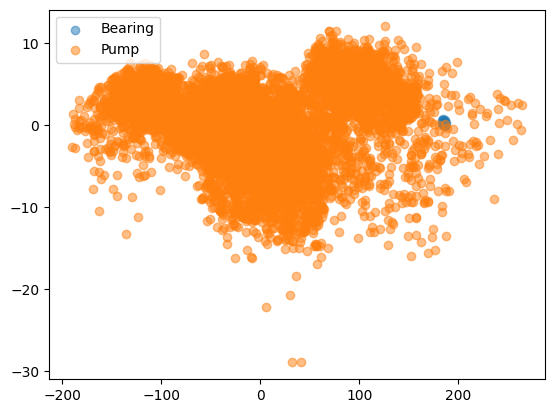

In [240]:
combined = np.vstack([bearing_scaled, X_pump_bearing_space])
labels_combined = (
    ["bearing"] * len(bearing_scaled) +
    ["pump"] * len(X_pump_bearing_space)
)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
proj = pca.fit_transform(combined)

plt.scatter(proj[:len(bearing_scaled),0],
            proj[:len(bearing_scaled),1],
            alpha=0.5,
            label="Bearing")

plt.scatter(proj[len(bearing_scaled):,0],
            proj[len(bearing_scaled):,1],
            alpha=0.5,
            label="Pump")

plt.legend()
plt.show()

In [242]:
import pandas as pd

df_stator = pd.read_excel(r"data\oil pump stators\DataSet - Copy.xlsx")

print("Shape:", df_stator.shape)
print("Columns:")
print(df_stator.columns)
print("\nFirst 5 rows:")
print(df_stator.head())

Shape: (102, 21)
Columns:
Index(['Peak_1', 'PeakAmplitude_1', 'Centroid_1', 'MeanAmplitude_1',
       'Skewness_1', 'Peak_2', 'PeakAmplitude_2', 'Centroid_2',
       'MeanAmplitude_2', 'Skewness_2', 'Peak_3', 'PeakAmplitude_3',
       'Centroid_3', 'MeanAmplitude_3', 'Skewness_3', 'Peak_4',
       'PeakAmplitude_4', 'Centroid_4', 'MeanAmplitude_4', 'Skewness_4',
       'Label'],
      dtype='str')

First 5 rows:
   Peak_1  PeakAmplitude_1   Centroid_1  MeanAmplitude_1  Skewness_1  Peak_2  \
0    4342         0.704139  3989.313375         0.005493   17.202361    8031   
1    4323         0.711961  4019.927345         0.007086   14.829893    8032   
2    4323         0.848359  3793.683909         0.011297   15.606170    8014   
3    4328         0.810828  3752.654543         0.013233   14.215286    8012   
4    4322         0.423710  3689.213988         0.010281   12.465707    8025   

   PeakAmplitude_2   Centroid_2  MeanAmplitude_2  Skewness_2  ...  \
0              1.0  7705.183719   

In [244]:
import numpy as np

labels = (
    ["good"] * 40 +
    ["cracked"] * 26 +
    ["tooth_breakage"] * 16 +
    ["fractured"] * 20
)

df_stator["fault_label"] = labels

print(df_stator["fault_label"].value_counts())

fault_label
good              40
cracked           26
fractured         20
tooth_breakage    16
Name: count, dtype: int64


In [249]:
df_stator

,Peak_1,PeakAmplitude_1,Centroid_1,MeanAmplitude_1,Skewness_1,Peak_2,PeakAmplitude_2,Centroid_2,MeanAmplitude_2,Skewness_2,...,Centroid_3,MeanAmplitude_3,Skewness_3,Peak_4,PeakAmplitude_4,Centroid_4,MeanAmplitude_4,Skewness_4,Label,fault_label
0,4342,0.704139,3989.313375,0.005493,17.202361,8031,1.000000,7705.183719,0.009643,14.633687,...,13500.720099,0.002247,11.344512,19900,0.007668,17112.837715,0.000575,4.105146,1,good
1,4323,0.711961,4019.927345,0.007086,14.829893,8032,1.000000,7673.564718,0.013843,11.519241,...,13856.109961,0.004232,12.055528,19844,0.010321,16939.250869,0.000812,3.470612,1,good
2,4323,0.848359,3793.683909,0.011297,15.606170,8014,1.000000,7514.676802,0.019237,9.130944,...,13243.378149,0.016756,7.141130,15012,0.015779,16863.423371,0.004011,0.793644,1,good
3,4328,0.810828,3752.654543,0.013233,14.215286,8012,1.000000,7635.209576,0.024425,10.290361,...,13707.091798,0.013388,8.455562,15827,0.022647,16701.965202,0.002364,2.965551,1,good
4,4322,0.423710,3689.213988,0.010281,12.465707,8025,1.000000,7614.511855,0.021091,8.960773,...,13313.892325,0.016830,6.491424,15001,0.017540,16696.715533,0.002422,2.328217,1,good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,4297,0.917043,3793.096246,0.012027,15.781230,7935,1.000000,7548.277915,0.018936,12.122698,...,13948.032700,0.016216,7.394033,15594,0.025674,16546.061211,0.002015,4.742974,2,fractured
98,4311,1.000000,3880.172953,0.011813,14.593350,7992,0.681714,7509.343708,0.012114,10.953452,...,13447.940188,0.010161,4.351074,15784,0.011174,16723.744807,0.002117,1.571796,2,fractured
99,4301,1.000000,3860.049343,0.018222,12.666981,7951,0.466678,7211.677589,0.020355,6.590114,...,12824.623954,0.011283,5.639676,15521,0.011059,16636.872303,0.003328,0.580064,2,fractured
100,1549,0.086279,3556.990311,0.011713,2.513422,7927,1.000000,7444.993158,0.022974,10.569841,...,13521.329281,0.013028,3.335163,15041,0.011286,16742.272093,0.002140,1.918221,2,fractured


In [252]:
#feature_columns = df_stator.select_dtypes(include=['float64','int64']).columns
feature_columns = df_stator.drop(columns=["fault_label",'Label'])

X_stator = feature_columns
y_stator = df_stator["fault_label"].values

print("Feature shape:", X_stator.shape)

Feature shape: (102, 20)


In [265]:
import numpy as np
import librosa

import numpy as np
import librosa

TARGET_SR = 16000

# Adjusted bands to fit Nyquist = 8000 Hz
bands = [
    (1000, 3000),
    (3000, 5000),
    (5000, 6500),
    (6500, 8000)
]

def extract_band_features(segment, sr=TARGET_SR):

    S = np.abs(librosa.stft(segment, n_fft=2048))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)

    features = []

    for low, high in bands:

        band_mask = (freqs >= low) & (freqs < high)

        if band_mask.sum() == 0:
            features.extend([0, 0, 0, 0, 0])
            continue

        band_spectrum = S[band_mask, :]
        magnitude = band_spectrum.flatten()

        if magnitude.size == 0:
            features.extend([0, 0, 0, 0, 0])
            continue

        # Peak Amplitude
        peak_amp = magnitude.max()

        # Peak Frequency
        band_energy = band_spectrum.mean(axis=1)
        peak_idx = np.argmax(band_energy)
        peak_freq = freqs[band_mask][peak_idx]

        # Centroid
        centroid = (freqs[band_mask] @ band_energy) / (band_energy.sum() + 1e-8)

        # Mean Amplitude
        mean_amp = magnitude.mean()

        # Skewness
        std = np.std(magnitude)
        skewness = ((magnitude - mean_amp)**3).mean() / (std**3 + 1e-8)

        features.extend([
            peak_amp,
            peak_freq,
            centroid,
            mean_amp,
            skewness
        ])

    return np.array(features)

In [266]:
pump_band_features = []

for seg in X_audio:
    f = extract_band_features(seg)
    pump_band_features.append(f)

pump_band_features = np.array(pump_band_features)

print("Pump band feature shape:", pump_band_features.shape)

Pump band feature shape: (8410, 20)


In [267]:
from sklearn.preprocessing import StandardScaler

stator_scaler = StandardScaler()
X_stator_scaled = stator_scaler.fit_transform(X_stator)

In [268]:
X_pump_stator_space = stator_scaler.transform(pump_band_features)

d:\College\TCG\tcg\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [269]:
mask = cluster_labels != -1

X_valid = X_pump_stator_space[mask]
clusters_valid = cluster_labels[mask]

cluster_means = {}

for c in np.unique(clusters_valid):
    cluster_means[c] = X_valid[clusters_valid == c].mean(axis=0)

In [271]:
fault_library_stator = {}

for fault in np.unique(y_stator):
    fault_data = X_stator_scaled[y_stator == fault]

    fault_library_stator[fault] = {
        "mean": fault_data.mean(axis=0),
        "cov": np.cov(fault_data.T)
    }

print(fault_library_stator.keys())

dict_keys(['cracked', 'fractured', 'good', 'tooth_breakage'])


In [272]:
from scipy.spatial.distance import mahalanobis
import numpy.linalg as LA

cluster_fault_mapping = {}

for cluster_id, cluster_vec in cluster_means.items():

    best_fault = None
    min_distance = float("inf")

    for fault, stats in fault_library_stator.items():

        cov_inv = LA.pinv(stats["cov"])
        dist = mahalanobis(cluster_vec, stats["mean"], cov_inv)

        if dist < min_distance:
            min_distance = dist
            best_fault = fault

    cluster_fault_mapping[cluster_id] = {
        "matched_fault": best_fault,
        "distance": min_distance
    }

print(cluster_fault_mapping)

{np.int64(0): {'matched_fault': 'cracked', 'distance': np.float64(125329.8527571027)}, np.int64(1): {'matched_fault': 'cracked', 'distance': np.float64(125325.80116606763)}, np.int64(2): {'matched_fault': 'cracked', 'distance': np.float64(131939.0217437717)}, np.int64(3): {'matched_fault': 'cracked', 'distance': np.float64(130864.62534305581)}, np.int64(4): {'matched_fault': 'cracked', 'distance': np.float64(130391.2591225796)}, np.int64(5): {'matched_fault': 'cracked', 'distance': np.float64(127347.9140133289)}, np.int64(6): {'matched_fault': 'cracked', 'distance': np.float64(132224.96590596653)}, np.int64(7): {'matched_fault': 'cracked', 'distance': np.float64(129618.85422197521)}, np.int64(8): {'matched_fault': 'cracked', 'distance': np.float64(125990.03325900299)}, np.int64(9): {'matched_fault': 'cracked', 'distance': np.float64(128891.93480863707)}, np.int64(10): {'matched_fault': 'cracked', 'distance': np.float64(126940.58769792489)}, np.int64(11): {'matched_fault': 'cracked', 'd

In [273]:
import pandas as pd

results = []

for idx, c in enumerate(clusters_valid):
    results.append((
        y[mask][idx],
        cluster_fault_mapping[c]["matched_fault"]
    ))

df_results = pd.DataFrame(results, columns=["true_label", "matched_fault"])

print(df_results.groupby("matched_fault")["true_label"].mean())

matched_fault
cracked    0.056693
Name: true_label, dtype: float64


In [274]:
for c, info in cluster_fault_mapping.items():
    print(c, info["matched_fault"], info["distance"])

0 cracked 125329.8527571027
1 cracked 125325.80116606763
2 cracked 131939.0217437717
3 cracked 130864.62534305581
4 cracked 130391.2591225796
5 cracked 127347.9140133289
6 cracked 132224.96590596653
7 cracked 129618.85422197521
8 cracked 125990.03325900299
9 cracked 128891.93480863707
10 cracked 126940.58769792489
11 cracked 132515.1118406029
12 cracked 119686.21123977214
13 cracked 125557.9319278289


In [277]:
import numpy.linalg as LA

for fault, stats in fault_library_stator.items():
    print(fault, LA.cond(stats["cov"]))

cracked 5483.415924629898
fractured 1.268836799051033e+19
good 203555.39583876418
tooth_breakage 7.183931964180532e+18


In [278]:
for fault, stats in fault_library_stator.items():
    mean = stats["mean"]
    cov_inv = np.linalg.pinv(stats["cov"])

    dists = []
    for x in X_stator_scaled[y_stator == fault]:
        d = mahalanobis(x, mean, cov_inv)
        dists.append(d)

    print(fault, np.mean(dists), np.max(dists))

cracked 4.365161917431626 4.83183557067506
fractured 4.248529157249558 4.2485291572496084
good 4.365272133100627 5.749286252881499
tooth_breakage 3.7500000000000027 3.75000000000003


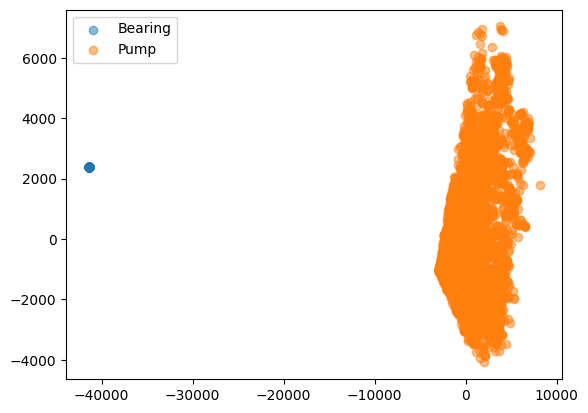

In [276]:
combined = np.vstack([X_stator_scaled, X_pump_stator_space])
labels_combined = (
    ["bearing"] * len(X_stator_scaled) +
    ["pump"] * len(X_pump_stator_space)
)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
proj = pca.fit_transform(combined)

plt.scatter(proj[:len(X_stator_scaled),0],
            proj[:len(X_stator_scaled),1],
            alpha=0.5,
            label="Stators")

plt.scatter(proj[len(X_stator_scaled):,0],
            proj[len(X_stator_scaled):,1],
            alpha=0.5,
            label="Pump")

plt.legend()
plt.show()

#### Setup different doesnot maps properly

In [280]:
import pandas as pd

df_cav = pd.read_excel(r"data\cavitation\Data_Mallet_Tube_Cavitation_Pan et al. - Copy.xlsx")

print("Shape:", df_cav.shape)
print("Columns:")
print(df_cav.columns)
print("\nFirst 5 rows:")
print(df_cav.head())

Shape: (55, 7)
Columns:
Index(['Experiment', 'Max (a/g)', 'Label', 'Height of the liquid column [mm]',
       'Minimum Acoustic Pressure (Abs. value) [Pa] ',
       'Minimum Acoustic Pressure [Pa] ', 'Average acoustic frequency [Hz]'],
      dtype='str')

First 5 rows:
  Experiment  Max (a/g)  Label  Height of the liquid column [mm]  \
0      cav_1   448.3180      0                              21.0   
1      cav_2   380.0580      0                              21.0   
2      cav_3   465.1980      0                              21.0   
3      cav_4   285.7850      1                              21.0   
4      cav_5    96.6253      1                              21.0   

   Minimum Acoustic Pressure (Abs. value) [Pa]   \
0                                       90221.2   
1                                       89368.0   
2                                      153332.0   
3                                       75214.9   
4                                       23902.0   

   Minimum Aco

In [282]:
import numpy as np

df_cav["fault_label"] = df_cav["Label"].map({0:"no-cavitation", 1:"cavitation"})


print(df_cav["fault_label"].value_counts())

fault_label
no-cavitation    29
cavitation       26
Name: count, dtype: int64


In [299]:
feature_columns = df_cav.drop(columns=["fault_label",'Label',"Experiment"])

#X_cav = feature_columns
X_cav=df_cav[
    [
        "Minimum Acoustic Pressure (Abs. value) [Pa] ",
        "Average acoustic frequency [Hz]"
    ]
]
y_cav = df_cav["fault_label"].values

print("Feature shape:", X_cav.shape)

Feature shape: (55, 2)


In [300]:
from sklearn.preprocessing import StandardScaler

cav_scaler = StandardScaler()
X_cav_scaled = cav_scaler.fit_transform(X_cav)

In [301]:
fault_library_cav = {}

for label in np.unique(y_cav):
    data = X_cav_scaled[y_cav == label]

    fault_library_cav[label] = {
        "mean": data.mean(axis=0),
        "cov": np.cov(data.T)
    }

print(fault_library_cav.keys())

dict_keys(['cavitation', 'no-cavitation'])


In [302]:
import librosa

def extract_cavitation_like_features(segment, sr=16000):

    rms = librosa.feature.rms(y=segment).mean()
    centroid = librosa.feature.spectral_centroid(y=segment, sr=sr).mean()

    return np.array([rms, centroid])

In [303]:
pump_cav_features = []

for seg in X_audio:
    f = extract_cavitation_like_features(seg)
    pump_cav_features.append(f)

pump_cav_features = np.array(pump_cav_features)

print(pump_cav_features.shape)

(8410, 2)


In [304]:
X_pump_cav_space = cav_scaler.transform(pump_cav_features)

d:\College\TCG\tcg\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [305]:
mask = cluster_labels != -1

X_valid = X_pump_cav_space[mask]
clusters_valid = cluster_labels[mask]

cluster_means = {}

for c in np.unique(clusters_valid):
    cluster_means[c] = X_valid[clusters_valid == c].mean(axis=0)

In [306]:
from scipy.spatial.distance import mahalanobis
import numpy.linalg as LA

cluster_fault_mapping = {}

for cluster_id, vec in cluster_means.items():

    best_label = None
    min_dist = float("inf")

    for label, stats in fault_library_cav.items():

        cov_inv = LA.pinv(stats["cov"])
        dist = mahalanobis(vec, stats["mean"], cov_inv)

        if dist < min_dist:
            min_dist = dist
            best_label = label

    cluster_fault_mapping[cluster_id] = {
        "matched_label": best_label,
        "distance": min_dist
    }

print(cluster_fault_mapping)

{np.int64(0): {'matched_label': 'no-cavitation', 'distance': np.float64(6.299434818219018)}, np.int64(1): {'matched_label': 'no-cavitation', 'distance': np.float64(5.5688822287106765)}, np.int64(2): {'matched_label': 'no-cavitation', 'distance': np.float64(3.9637276296993034)}, np.int64(3): {'matched_label': 'cavitation', 'distance': np.float64(2.0617630689195994)}, np.int64(4): {'matched_label': 'no-cavitation', 'distance': np.float64(2.701377000170421)}, np.int64(5): {'matched_label': 'no-cavitation', 'distance': np.float64(3.8288128070573806)}, np.int64(6): {'matched_label': 'no-cavitation', 'distance': np.float64(3.8272942191982247)}, np.int64(7): {'matched_label': 'no-cavitation', 'distance': np.float64(3.934744684391662)}, np.int64(8): {'matched_label': 'cavitation', 'distance': np.float64(2.3891063035477904)}, np.int64(9): {'matched_label': 'no-cavitation', 'distance': np.float64(2.8593023652564655)}, np.int64(10): {'matched_label': 'no-cavitation', 'distance': np.float64(4.0264

In [307]:
import pandas as pd

results = []

for idx, c in enumerate(clusters_valid):
    results.append((
        y[mask][idx],
        cluster_fault_mapping[c]["matched_label"]
    ))

df_results = pd.DataFrame(results, columns=["true_label", "matched_label"])

print(df_results.groupby("matched_label")["true_label"].mean())

matched_label
cavitation       0.011236
no-cavitation    0.058507
Name: true_label, dtype: float64


In [309]:
for c, info in cluster_fault_mapping.items():
    print(c, info["matched_label"], info["distance"])

0 no-cavitation 6.299434818219018
1 no-cavitation 5.5688822287106765
2 no-cavitation 3.9637276296993034
3 cavitation 2.0617630689195994
4 no-cavitation 2.701377000170421
5 no-cavitation 3.8288128070573806
6 no-cavitation 3.8272942191982247
7 no-cavitation 3.934744684391662
8 cavitation 2.3891063035477904
9 no-cavitation 2.8593023652564655
10 no-cavitation 4.026441346404502
11 no-cavitation 3.5676843389055772
12 cavitation 2.3868155868649428
13 no-cavitation 3.1289365703416587


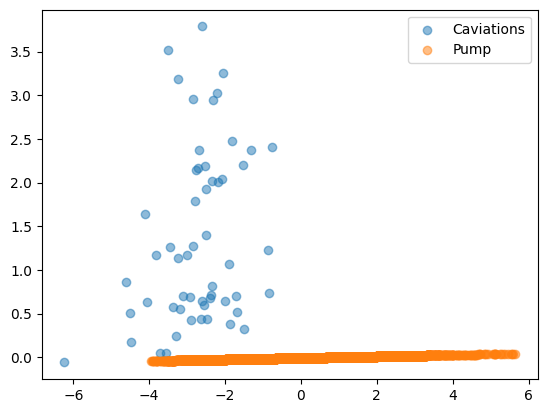

In [310]:
combined = np.vstack([X_cav_scaled, X_pump_cav_space])
labels_combined = (
    ["bearing"] * len(X_cav_scaled) +
    ["pump"] * len(X_pump_cav_space)
)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
proj = pca.fit_transform(combined)

plt.scatter(proj[:len(X_cav_scaled),0],
            proj[:len(X_cav_scaled),1],
            alpha=0.5,
            label="Caviations")

plt.scatter(proj[len(X_cav_scaled):,0],
            proj[len(X_cav_scaled):,1],
            alpha=0.5,
            label="Pump")

plt.legend()
plt.show()